In [44]:
import numpy as np
import matplotlib.pyplot as plt

In [45]:
X = np.array([
    [40, 15, 5],
    [65, 35, 8],
    [120, 80, 15],
    [30, 0, 2],
    [150, 120, 25],
    [85, 50, 10],
    [100, 65, 12],
    [45, 20, 6],
    [200, 180, 35],
    [70, 40, 8]
])

y = np.array([750, 1100, 2300, 450, 3100, 1600, 1950, 850, 4200, 1250])
w = np.zeros(3)
b = 0
alpha = 0.1

In [46]:
def calcular_desvio(X):
    sigma = np.std(X, axis=0)
    mu = np.mean(X, axis=0)
    X_norm = (X-mu)/sigma 
    return X_norm, mu, sigma
X_norm, mu, sigma = calcular_desvio(X)

In [47]:
def calcular_custo(X, y, w, b):
    m = len(y)
    previsao = np.dot(X, w) + b
    J = np.sum((previsao - y) ** 2) 
    J = J / (2 * m)
    return J

In [48]:
def calcular_gradiente(X,y,w,b):
    m = len(y)
    previsao = np.dot(X, w) + b
    erro = previsao - y
    dj_db = np.sum(erro) / m
    dj_dw = np.dot(X.T,erro) / m
    return dj_dw,dj_db

In [49]:
def treinar_ia(X, y, w_in, b_in, alpha, num_itens):
    w = np.copy(w_in)
    b = b_in
    historico_custo = []

    for i in range(num_itens):
        dj_dw, dj_db = calcular_gradiente(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        custo_atual = calcular_custo(X, y, w, b)
        historico_custo.append(custo_atual)
        if i % 100 == 0:
            print(f"Iteração {i:4d} | Custo J: {custo_atual:8.2f}")
            
    return w, b, historico_custo

In [50]:
config_alpha = 0.01
iteracoes = 1000

w_final, b_final, hist = treinar_ia(X_norm, y, w, b, config_alpha, iteracoes)

print("\n--- TREINO CONCLUÍDO ---")
print(f"Pesos finais descobertos: {w_final}")
print(f"Viés final (ponto de partida): {b_final}")

Iteração    0 | Custo J: 2091302.42
Iteração  100 | Custo J: 205875.96
Iteração  200 | Custo J: 29344.96
Iteração  300 | Custo J:  5836.06
Iteração  400 | Custo J:  2651.96
Iteração  500 | Custo J:  2191.72
Iteração  600 | Custo J:  2097.55
Iteração  700 | Custo J:  2053.50
Iteração  800 | Custo J:  2017.23
Iteração  900 | Custo J:  1983.01

--- TREINO CONCLUÍDO ---
Pesos finais descobertos: [416.78296315 366.72904756 329.64205524]
Viés final (ponto de partida): 1754.9242344607947


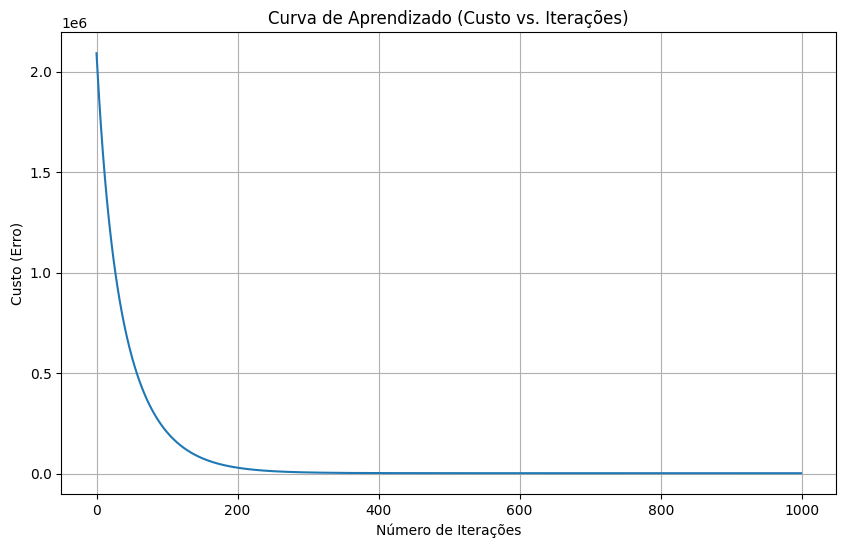

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(hist)

plt.title("Curva de Aprendizado (Custo vs. Iterações)")
plt.xlabel("Número de Iterações")
plt.ylabel("Custo (Erro)")
plt.grid(True)
plt.show()

In [52]:

x_amanha_bruto = np.array([120, 50, 10])

x_amanha_norm = (x_amanha_bruto - mu) / sigma

faturamento_previsto = np.dot(x_amanha_norm, w_final) + b_final

print(f"--- PREVISÃO PARA AMANHÃ ---")
print(f"Com {x_amanha_bruto[0]} clientes e R${x_amanha_bruto[1]} em Ads...")
print(f"O faturamento estimado é de: R$ {faturamento_previsto:.2f}")


--- PREVISÃO PARA AMANHÃ ---
Com 120 clientes e R$50 em Ads...
O faturamento estimado é de: R$ 1833.08


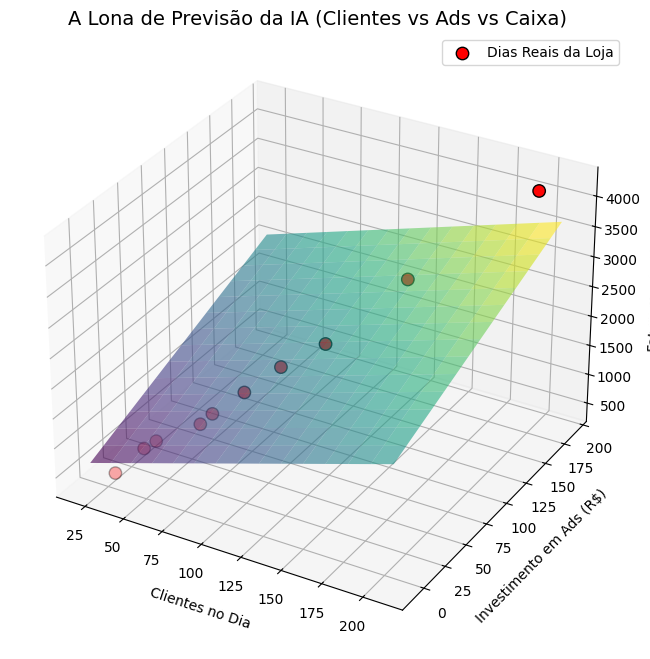

In [53]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], y, color='red', s=80, label='Dias Reais da Loja', edgecolors='black')

clientes_range = np.linspace(X[:, 0].min() - 10, X[:, 0].max() + 10, 15)
ads_range = np.linspace(X[:, 1].min() - 10, X[:, 1].max() + 10, 15)
clientes_grid, ads_grid = np.meshgrid(clientes_range, ads_range)

faturamento_pred_lona = np.zeros(clientes_grid.shape)

for i in range(clientes_grid.shape[0]):
    for j in range(clientes_grid.shape[1]):
        dia_malha = np.array([clientes_grid[i,j], ads_grid[i,j], mu[2]])
        dia_norm = (dia_malha - mu) / sigma
        faturamento_pred_lona[i,j] = np.dot(dia_norm, w_final) + b_final

ax.plot_surface(clientes_grid, ads_grid, faturamento_pred_lona, alpha=0.6, cmap='viridis')

ax.set_title('A Lona de Previsão da IA (Clientes vs Ads vs Caixa)', fontsize=14)
ax.set_xlabel('\nClientes no Dia')
ax.set_ylabel('\nInvestimento em Ads (R$)')
ax.set_zlabel('\nFaturamento (R$)')
ax.legend()
plt.show()